# 🎓 Student Performance Predictor
### Predicting Academic Outcomes Using Machine Learning

---

**Author:** Takunda Manhongo  
**Programme:** BSc Data Science & Systems — University of Zimbabwe  
**Date:** March 2026  
**Dataset:** UCI Student Performance Dataset · 395 Students · 33 Features

---

## 📌 Table of Contents
1. [Dataset Description](#1-dataset-description)
2. [Objectives](#2-objectives)
3. [Setup & Imports](#3-setup--imports)
4. [Data Loading & Inspection](#4-data-loading--inspection)
5. [Data Preprocessing](#5-data-preprocessing)
6. [Exploratory Data Analysis](#6-exploratory-data-analysis)
   - 6.1 Grade Distribution & Pass Rate
   - 6.2 Impact of Study Habits
   - 6.3 Family & Social Factors
   - 6.4 Alcohol & Lifestyle Effects
   - 6.5 Correlation Analysis
7. [Feature Engineering](#7-feature-engineering)
8. [Machine Learning Models](#8-machine-learning-models)
   - 8.1 Regression — Predicting Final Grade (G3)
   - 8.2 Classification — Pass / Fail Prediction
9. [Model Evaluation & Comparison](#9-model-evaluation--comparison)
10. [Feature Importance](#10-feature-importance)
11. [Key Findings & Recommendations](#11-key-findings--recommendations)

---


## 1. Dataset Description

This dataset contains academic and socio-demographic records of **395 secondary school students** 
from two Portuguese schools. It includes unique features rarely found in educational datasets, 
making it ideal for both regression (predicting grade) and classification (pass/fail) tasks.

| Feature | Description |
|---|---|
| `school` | Student school — GP or MS |
| `sex` | Student gender — F or M |
| `age` | Student age (15–22) |
| `address` | Urban (U) or Rural (R) |
| `famsize` | Family size — GT3 (>3) or LE3 (≤3) |
| `Pstatus` | Parent cohabitation — Together (T) or Apart (A) |
| `Medu / Fedu` | Mother/Father education (0–4 scale) |
| `Mjob / Fjob` | Mother/Father occupation |
| `studytime` | Weekly study time (1–4 scale) |
| `failures` | Number of past class failures |
| `schoolsup` | Extra educational support |
| `higher` | Wants to pursue higher education |
| `internet` | Internet access at home |
| `romantic` | In a romantic relationship |
| `famrel` | Family relationship quality (1–5) |
| `freetime` | Free time after school (1–5) |
| `goout` | Going out with friends (1–5) |
| `Dalc / Walc` | Weekday / Weekend alcohol consumption (1–5) |
| `health` | Current health status (1–5) |
| `absences` | Number of school absences |
| `G1 / G2 / G3` | First, second, and final period grades (0–20) |

> **Target Variable:** `G3` — Final period grade (0–20). A grade ≥ 10 is considered a **pass**.


## 2. Objectives

1. **Grade Distribution Analysis** — Understand how final grades are distributed and identify at-risk students
2. **Academic Factor Analysis** — Measure the impact of study time, failures, and absences on performance
3. **Family & Social Influence** — Quantify how parental education, family relations, and social life affect grades
4. **Lifestyle Effects** — Analyse how alcohol consumption, romantic relationships, and going out relate to grades
5. **Correlation Mapping** — Identify the strongest predictors of final grade
6. **Regression Modelling** — Build models to predict the exact final grade (G3)
7. **Classification Modelling** — Build models to predict whether a student will pass or fail
8. **Feature Importance** — Rank features by their predictive power
9. **Early Warning System** — Identify which student profiles are most at risk

> **Hypothesis:** Study time, past failures, and parental education are the strongest 
> non-grade predictors of academic performance.


## 3. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

PRIMARY  = '#4361ee'
ACCENT   = '#f72585'
SUCCESS  = '#4ade80'
WARNING  = '#f59e0b'
PALETTE  = [PRIMARY, ACCENT, '#4cc9f0', '#7209b7', SUCCESS]


## 4. Data Loading & Inspection

In [2]:
df = pd.read_csv('student_data.csv')

print('Dataset shape  :', df.shape[0], 'students x', df.shape[1], 'features')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
df.head(8)


Dataset shape  : 395 students x 33 features
Missing values : 0
Duplicate rows : 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6


In [3]:
df.describe().round(2)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71,10.91,10.71,10.42
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


In [4]:
# Categorical feature overview
cat_cols = df.select_dtypes(include='object').columns
summary = pd.DataFrame({
    'Unique Values': [df[c].nunique() for c in cat_cols],
    'Categories'   : [df[c].unique().tolist() for c in cat_cols]
}, index=cat_cols)
summary


,Unique Values,Categories
school,2,"[GP, MS]"
sex,2,"[F, M]"
address,2,"[U, R]"
famsize,2,"[GT3, LE3]"
Pstatus,2,"[A, T]"
Mjob,5,"[at_home, health, other, services, teacher]"
Fjob,5,"[teacher, other, services, health, at_home]"
reason,4,"[course, other, home, reputation]"
guardian,3,"[mother, father, other]"
schoolsup,2,"[yes, no]"


## 5. Data Preprocessing

In [5]:
# ── Pass/Fail target variable ────────────────────────────────
df['pass'] = (df['G3'] >= 10).astype(int)

# ── Grade band classification ─────────────────────────────────
def grade_band(g):
    if g == 0: return 'Absent/Zero'
    elif g < 10: return 'Fail (1–9)'
    elif g < 14: return 'Pass (10–13)'
    elif g < 17: return 'Merit (14–16)'
    else: return 'Distinction (17–20)'

df['grade_band'] = df['G3'].apply(grade_band)

# ── Combined alcohol index ─────────────────────────────────────
df['alc_total'] = (df['Dalc'] + df['Walc']) / 2

# ── Parental education average ────────────────────────────────
df['parent_edu'] = (df['Medu'] + df['Fedu']) / 2

# ── Encode categoricals for ML ────────────────────────────────
df_ml = df.copy()
le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print('New engineered features added:')
new_cols = ['pass', 'grade_band', 'alc_total', 'parent_edu']
for c in new_cols:
    print('  ' + str(c).ljust(15) + ' | ' + str(df[c].dtype) + '  sample: ' + str(df[c].unique()[:4].tolist()))


New engineered features added:
  pass            | int64  sample: [0, 1]
  grade_band      | str  sample: ['Fail (1–9)', 'Pass (10–13)', 'Merit (14–16)', 'Distinction (17–20)']
  alc_total       | float64  sample: [1.0, 2.5, 1.5, 2.0]
  parent_edu      | float64  sample: [4.0, 1.0, 3.0, 3.5]


## 6. Exploratory Data Analysis

### 6.1 Grade Distribution & Pass Rate

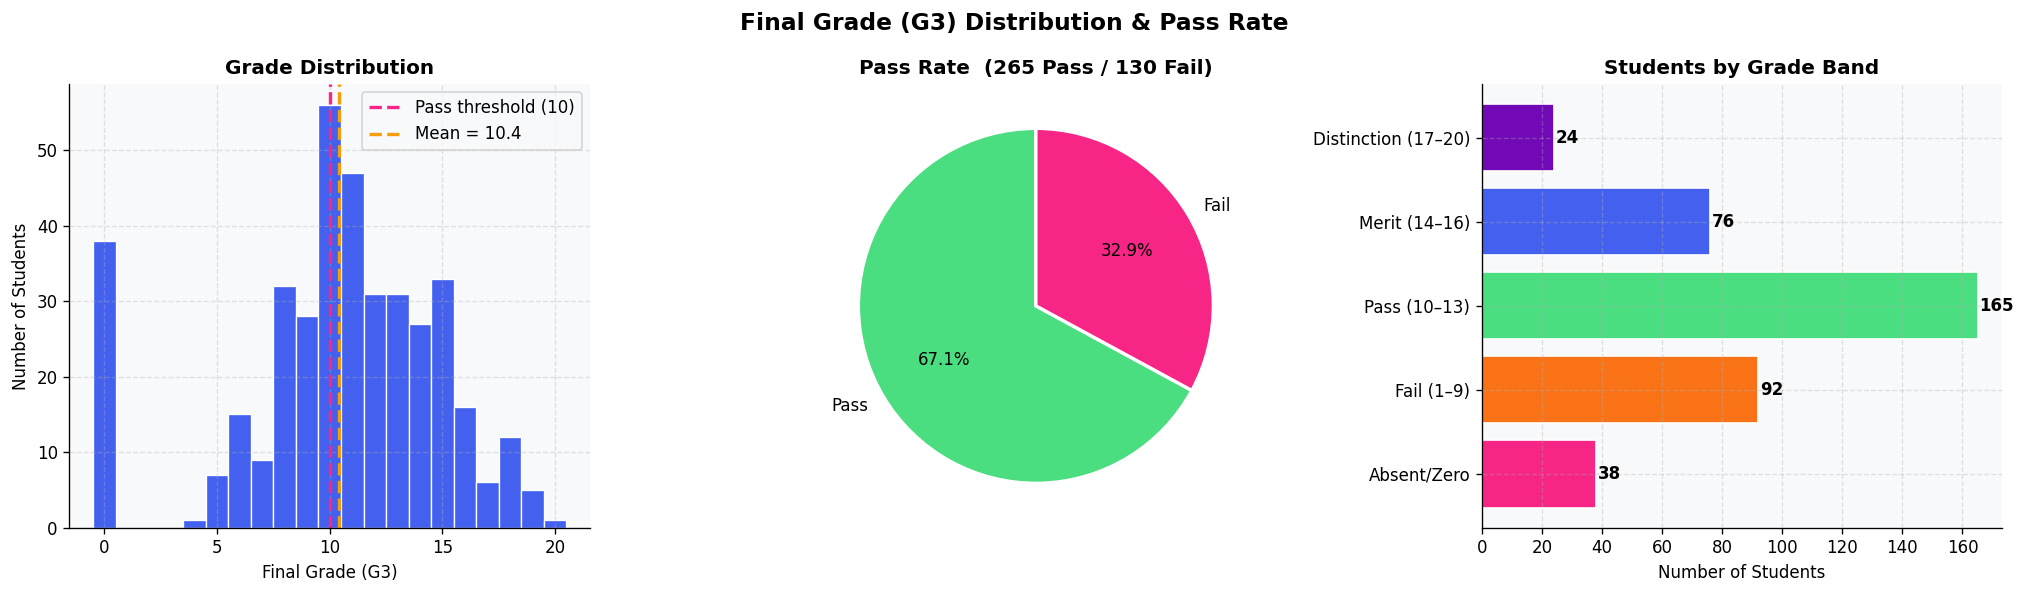

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Final Grade (G3) Distribution & Pass Rate', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df['G3'], bins=21, range=(-0.5, 20.5), color=PRIMARY, edgecolor='white', linewidth=0.8)
axes[0].axvline(10, color=ACCENT, linestyle='--', linewidth=2, label='Pass threshold (10)')
axes[0].axvline(df['G3'].mean(), color=WARNING, linestyle='--', linewidth=2, label=f'Mean = {df["G3"].mean():.1f}')
axes[0].set_title('Grade Distribution', fontweight='bold')
axes[0].set_xlabel('Final Grade (G3)')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

# Pass/Fail pie
pass_counts = df['pass'].value_counts()
axes[1].pie(pass_counts.values, labels=['Pass', 'Fail'],
            colors=[SUCCESS, ACCENT], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'Pass Rate  ({pass_counts[1]} Pass / {pass_counts[0]} Fail)', fontweight='bold')

# Grade band bar
band_order = ['Absent/Zero', 'Fail (1–9)', 'Pass (10–13)', 'Merit (14–16)', 'Distinction (17–20)']
band_counts = df['grade_band'].value_counts().reindex(band_order)
band_colors = [ACCENT, '#f97316', SUCCESS, PRIMARY, '#7209b7']
axes[2].barh(band_counts.index, band_counts.values, color=band_colors, edgecolor='white', linewidth=1)
axes[2].set_title('Students by Grade Band', fontweight='bold')
axes[2].set_xlabel('Number of Students')
for i, v in enumerate(band_counts.values):
    axes[2].text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_01_grade_distribution.png', bbox_inches='tight')
plt.show()


### 6.2 Impact of Study Habits on Performance

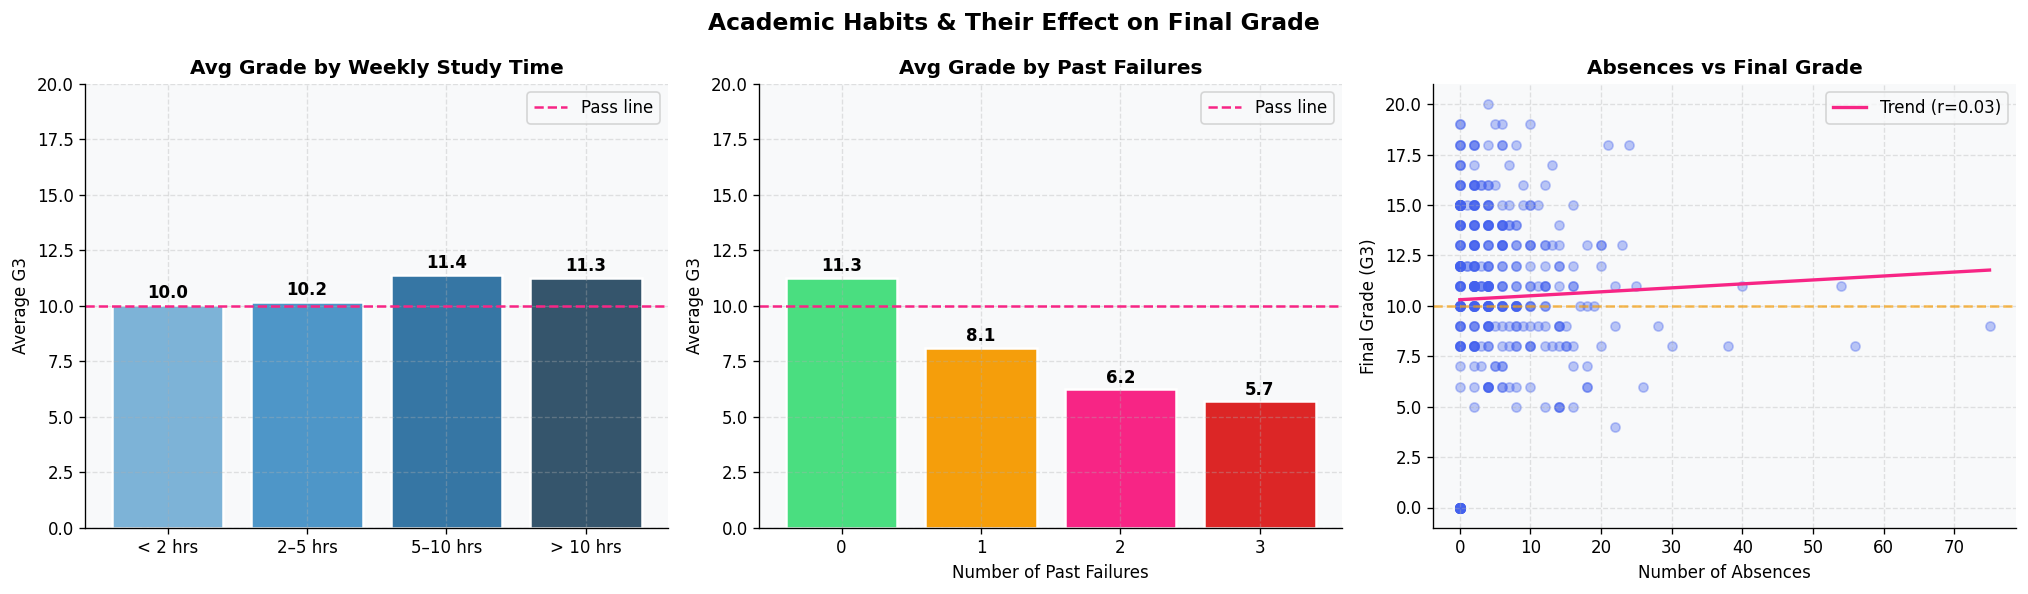

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Academic Habits & Their Effect on Final Grade', fontsize=14, fontweight='bold')

study_labels = {1: '< 2 hrs', 2: '2–5 hrs', 3: '5–10 hrs', 4: '> 10 hrs'}

# Study time vs G3
study_g3 = df.groupby('studytime')['G3'].mean()
axes[0].bar([study_labels[i] for i in study_g3.index], study_g3.values,
            color=sns.color_palette('Blues_d', 4), edgecolor='white', linewidth=1.5)
axes[0].axhline(10, color=ACCENT, linestyle='--', linewidth=1.5, label='Pass line')
axes[0].set_title('Avg Grade by Weekly Study Time', fontweight='bold')
axes[0].set_ylabel('Average G3')
axes[0].set_ylim(0, 20)
axes[0].legend()
for i, v in enumerate(study_g3.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

# Failures vs G3
fail_g3 = df.groupby('failures')['G3'].mean()
axes[1].bar(fail_g3.index.astype(str), fail_g3.values,
            color=[SUCCESS, WARNING, ACCENT, '#dc2626'], edgecolor='white', linewidth=1.5)
axes[1].axhline(10, color=ACCENT, linestyle='--', linewidth=1.5, label='Pass line')
axes[1].set_title('Avg Grade by Past Failures', fontweight='bold')
axes[1].set_xlabel('Number of Past Failures')
axes[1].set_ylabel('Average G3')
axes[1].set_ylim(0, 20)
axes[1].legend()
for i, v in enumerate(fail_g3.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

# Absences vs G3 scatter
axes[2].scatter(df['absences'], df['G3'], alpha=0.35, color=PRIMARY, s=30)
z = np.polyfit(df['absences'], df['G3'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['absences'].max(), 100)
axes[2].plot(x_line, p(x_line), color=ACCENT, linewidth=2, label=f'Trend (r={df["absences"].corr(df["G3"]):.2f})')
axes[2].axhline(10, color=WARNING, linestyle='--', linewidth=1.5, alpha=0.7)
axes[2].set_title('Absences vs Final Grade', fontweight='bold')
axes[2].set_xlabel('Number of Absences')
axes[2].set_ylabel('Final Grade (G3)')
axes[2].legend()

plt.tight_layout()
plt.savefig('plot_02_study_habits.png', bbox_inches='tight')
plt.show()


### 6.3 Family & Social Factors

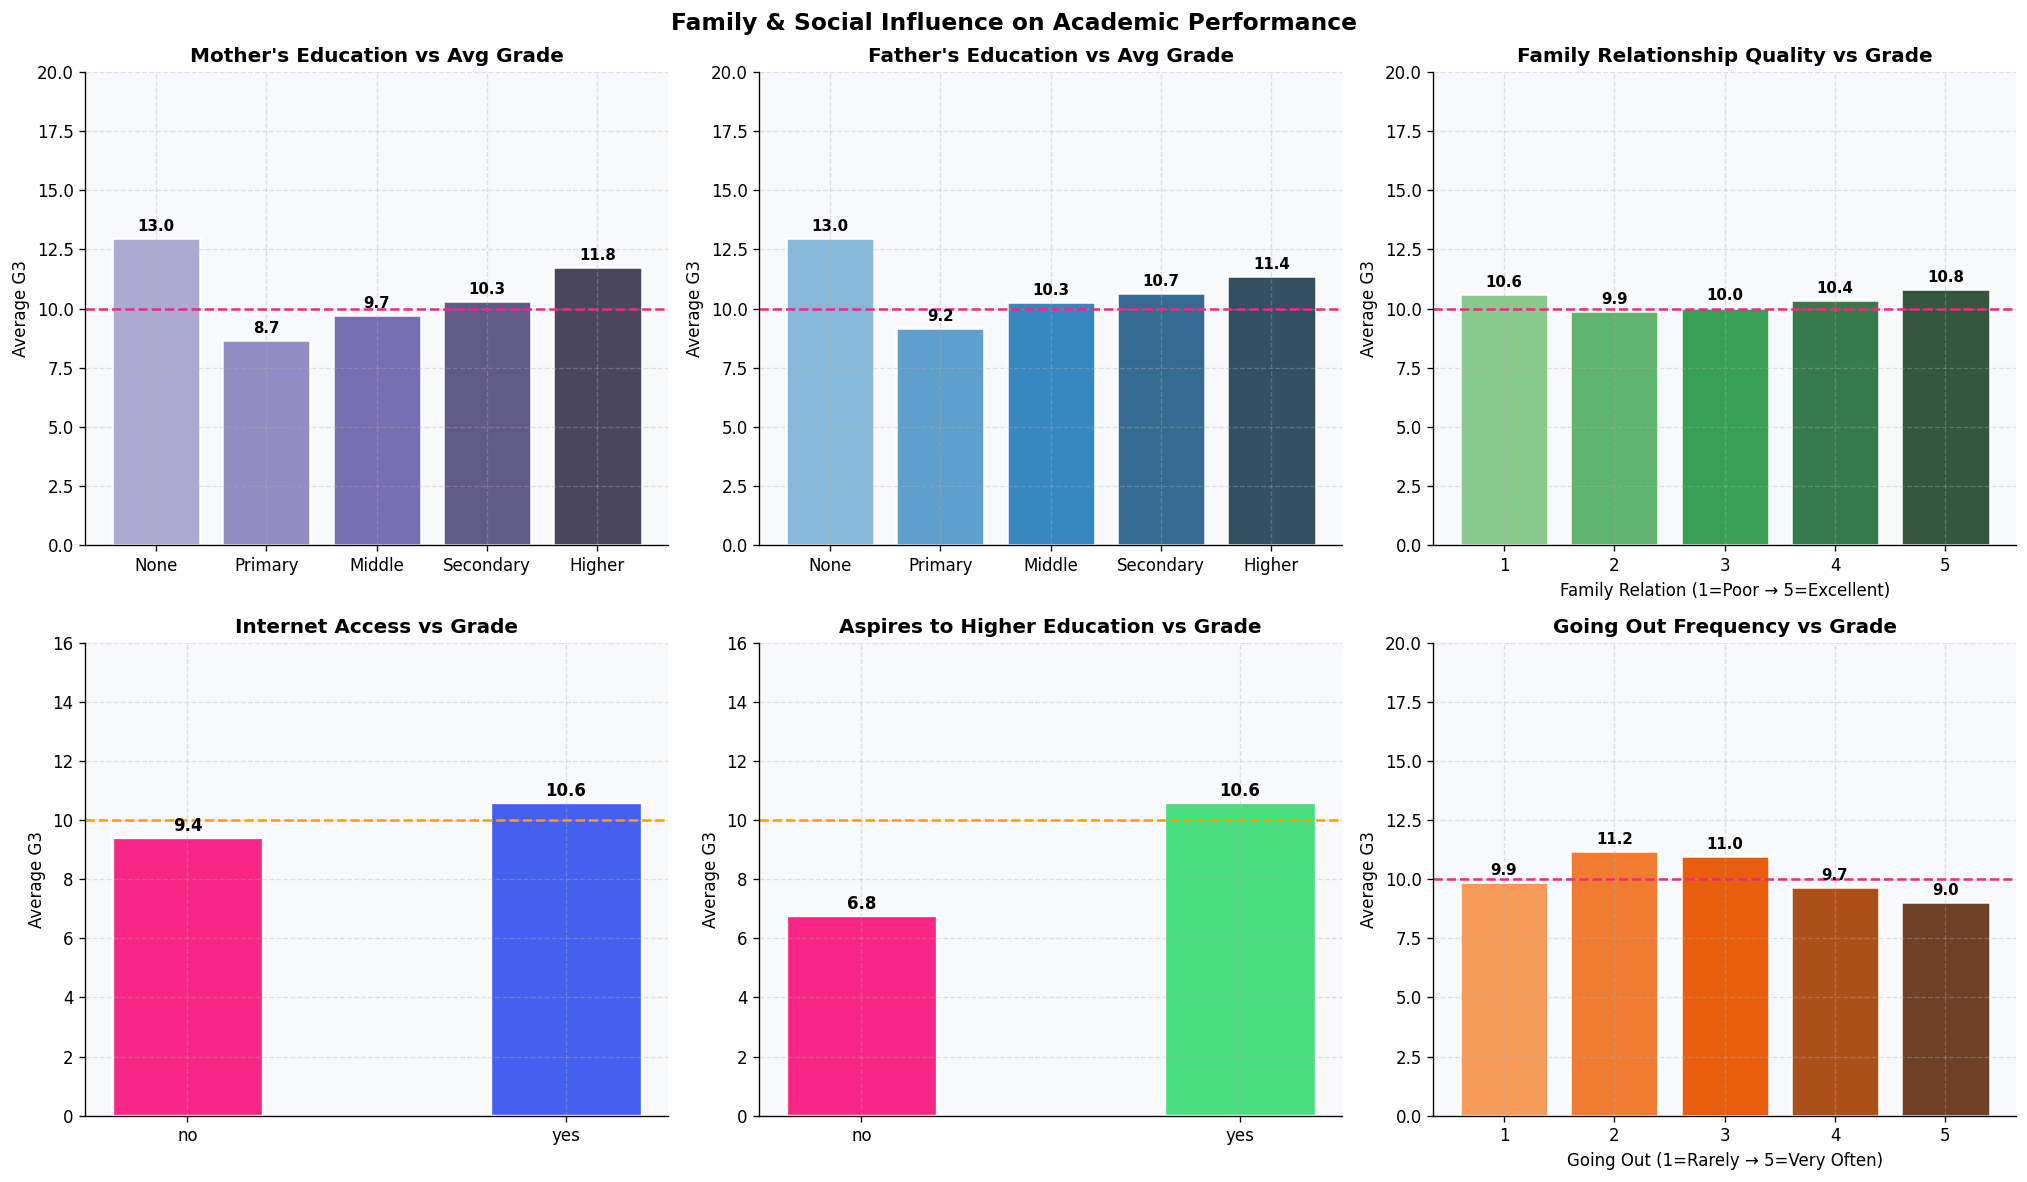

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Family & Social Influence on Academic Performance', fontsize=14, fontweight='bold')

# Mother education
medu_g3 = df.groupby('Medu')['G3'].mean()
edu_labels = {0:'None', 1:'Primary', 2:'Middle', 3:'Secondary', 4:'Higher'}
axes[0,0].bar([edu_labels[i] for i in medu_g3.index], medu_g3.values,
              color=sns.color_palette('Purples_d', 5), edgecolor='white', linewidth=1.5)
axes[0,0].axhline(10, color=ACCENT, linestyle='--', linewidth=1.5)
axes[0,0].set_title("Mother's Education vs Avg Grade", fontweight='bold')
axes[0,0].set_ylabel('Average G3')
axes[0,0].set_ylim(0, 20)
for i, v in enumerate(medu_g3.values):
    axes[0,0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Father education
fedu_g3 = df.groupby('Fedu')['G3'].mean()
axes[0,1].bar([edu_labels[i] for i in fedu_g3.index], fedu_g3.values,
              color=sns.color_palette('Blues_d', 5), edgecolor='white', linewidth=1.5)
axes[0,1].axhline(10, color=ACCENT, linestyle='--', linewidth=1.5)
axes[0,1].set_title("Father's Education vs Avg Grade", fontweight='bold')
axes[0,1].set_ylabel('Average G3')
axes[0,1].set_ylim(0, 20)
for i, v in enumerate(fedu_g3.values):
    axes[0,1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Family relations
famrel_g3 = df.groupby('famrel')['G3'].mean()
axes[0,2].bar(famrel_g3.index.astype(str), famrel_g3.values,
              color=sns.color_palette('Greens_d', 5), edgecolor='white', linewidth=1.5)
axes[0,2].axhline(10, color=ACCENT, linestyle='--', linewidth=1.5)
axes[0,2].set_title('Family Relationship Quality vs Grade', fontweight='bold')
axes[0,2].set_xlabel('Family Relation (1=Poor → 5=Excellent)')
axes[0,2].set_ylabel('Average G3')
axes[0,2].set_ylim(0, 20)
for i, v in enumerate(famrel_g3.values):
    axes[0,2].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Internet access
net_g3 = df.groupby('internet')['G3'].mean()
axes[1,0].bar(net_g3.index, net_g3.values, color=[ACCENT, PRIMARY], edgecolor='white', linewidth=2, width=0.4)
axes[1,0].axhline(10, color=WARNING, linestyle='--', linewidth=1.5)
axes[1,0].set_title('Internet Access vs Grade', fontweight='bold')
axes[1,0].set_ylabel('Average G3')
axes[1,0].set_ylim(0, 16)
for i, v in enumerate(net_g3.values):
    axes[1,0].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

# Aspires to higher education
higher_g3 = df.groupby('higher')['G3'].mean()
axes[1,1].bar(higher_g3.index, higher_g3.values, color=[ACCENT, SUCCESS], edgecolor='white', linewidth=2, width=0.4)
axes[1,1].axhline(10, color=WARNING, linestyle='--', linewidth=1.5)
axes[1,1].set_title('Aspires to Higher Education vs Grade', fontweight='bold')
axes[1,1].set_ylabel('Average G3')
axes[1,1].set_ylim(0, 16)
for i, v in enumerate(higher_g3.values):
    axes[1,1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

# Goout vs G3
goout_g3 = df.groupby('goout')['G3'].mean()
axes[1,2].bar(goout_g3.index.astype(str), goout_g3.values,
              color=sns.color_palette('Oranges_d', 5), edgecolor='white', linewidth=1.5)
axes[1,2].axhline(10, color=ACCENT, linestyle='--', linewidth=1.5)
axes[1,2].set_title('Going Out Frequency vs Grade', fontweight='bold')
axes[1,2].set_xlabel('Going Out (1=Rarely → 5=Very Often)')
axes[1,2].set_ylabel('Average G3')
axes[1,2].set_ylim(0, 20)
for i, v in enumerate(goout_g3.values):
    axes[1,2].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_03_family_social.png', bbox_inches='tight')
plt.show()


### 6.4 Alcohol & Lifestyle Effects

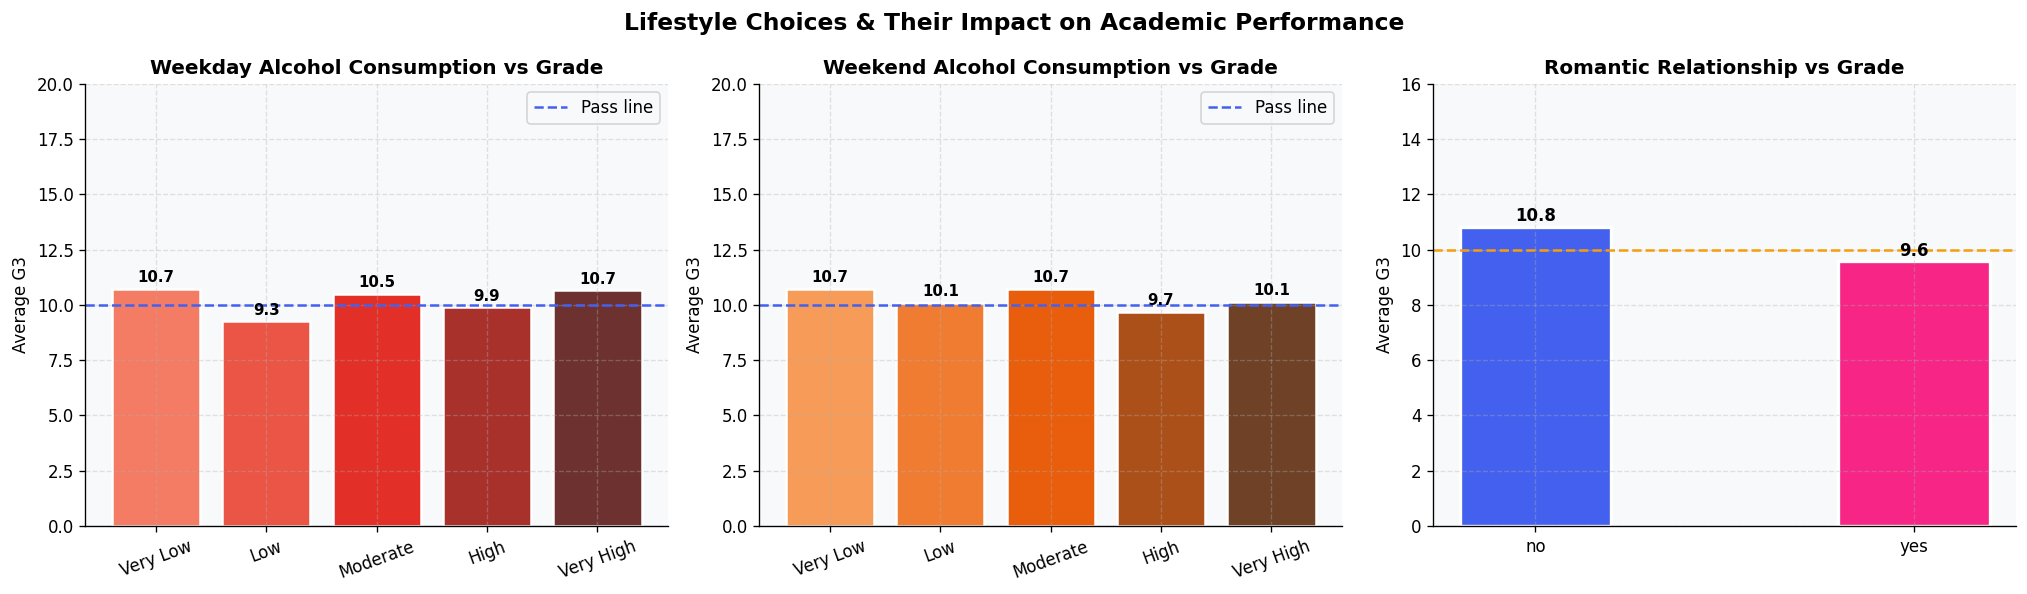

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Lifestyle Choices & Their Impact on Academic Performance', fontsize=14, fontweight='bold')

alc_labels = {1:'Very Low', 2:'Low', 3:'Moderate', 4:'High', 5:'Very High'}

# Weekday alcohol
dalc_g3 = df.groupby('Dalc')['G3'].mean()
axes[0].bar([alc_labels[i] for i in dalc_g3.index], dalc_g3.values,
            color=sns.color_palette('Reds_d', 5), edgecolor='white', linewidth=1.5)
axes[0].axhline(10, color=PRIMARY, linestyle='--', linewidth=1.5, label='Pass line')
axes[0].set_title('Weekday Alcohol Consumption vs Grade', fontweight='bold')
axes[0].set_ylabel('Average G3')
axes[0].set_ylim(0, 20)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()
for i, v in enumerate(dalc_g3.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Weekend alcohol
walc_g3 = df.groupby('Walc')['G3'].mean()
axes[1].bar([alc_labels[i] for i in walc_g3.index], walc_g3.values,
            color=sns.color_palette('Oranges_d', 5), edgecolor='white', linewidth=1.5)
axes[1].axhline(10, color=PRIMARY, linestyle='--', linewidth=1.5, label='Pass line')
axes[1].set_title('Weekend Alcohol Consumption vs Grade', fontweight='bold')
axes[1].set_ylabel('Average G3')
axes[1].set_ylim(0, 20)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()
for i, v in enumerate(walc_g3.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Romantic relationship
romantic_g3 = df.groupby('romantic')['G3'].mean()
axes[2].bar(romantic_g3.index, romantic_g3.values,
            color=[PRIMARY, ACCENT], edgecolor='white', linewidth=2, width=0.4)
axes[2].axhline(10, color=WARNING, linestyle='--', linewidth=1.5)
axes[2].set_title('Romantic Relationship vs Grade', fontweight='bold')
axes[2].set_ylabel('Average G3')
axes[2].set_ylim(0, 16)
for i, v in enumerate(romantic_g3.values):
    axes[2].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_04_lifestyle.png', bbox_inches='tight')
plt.show()


### 6.5 Correlation Analysis

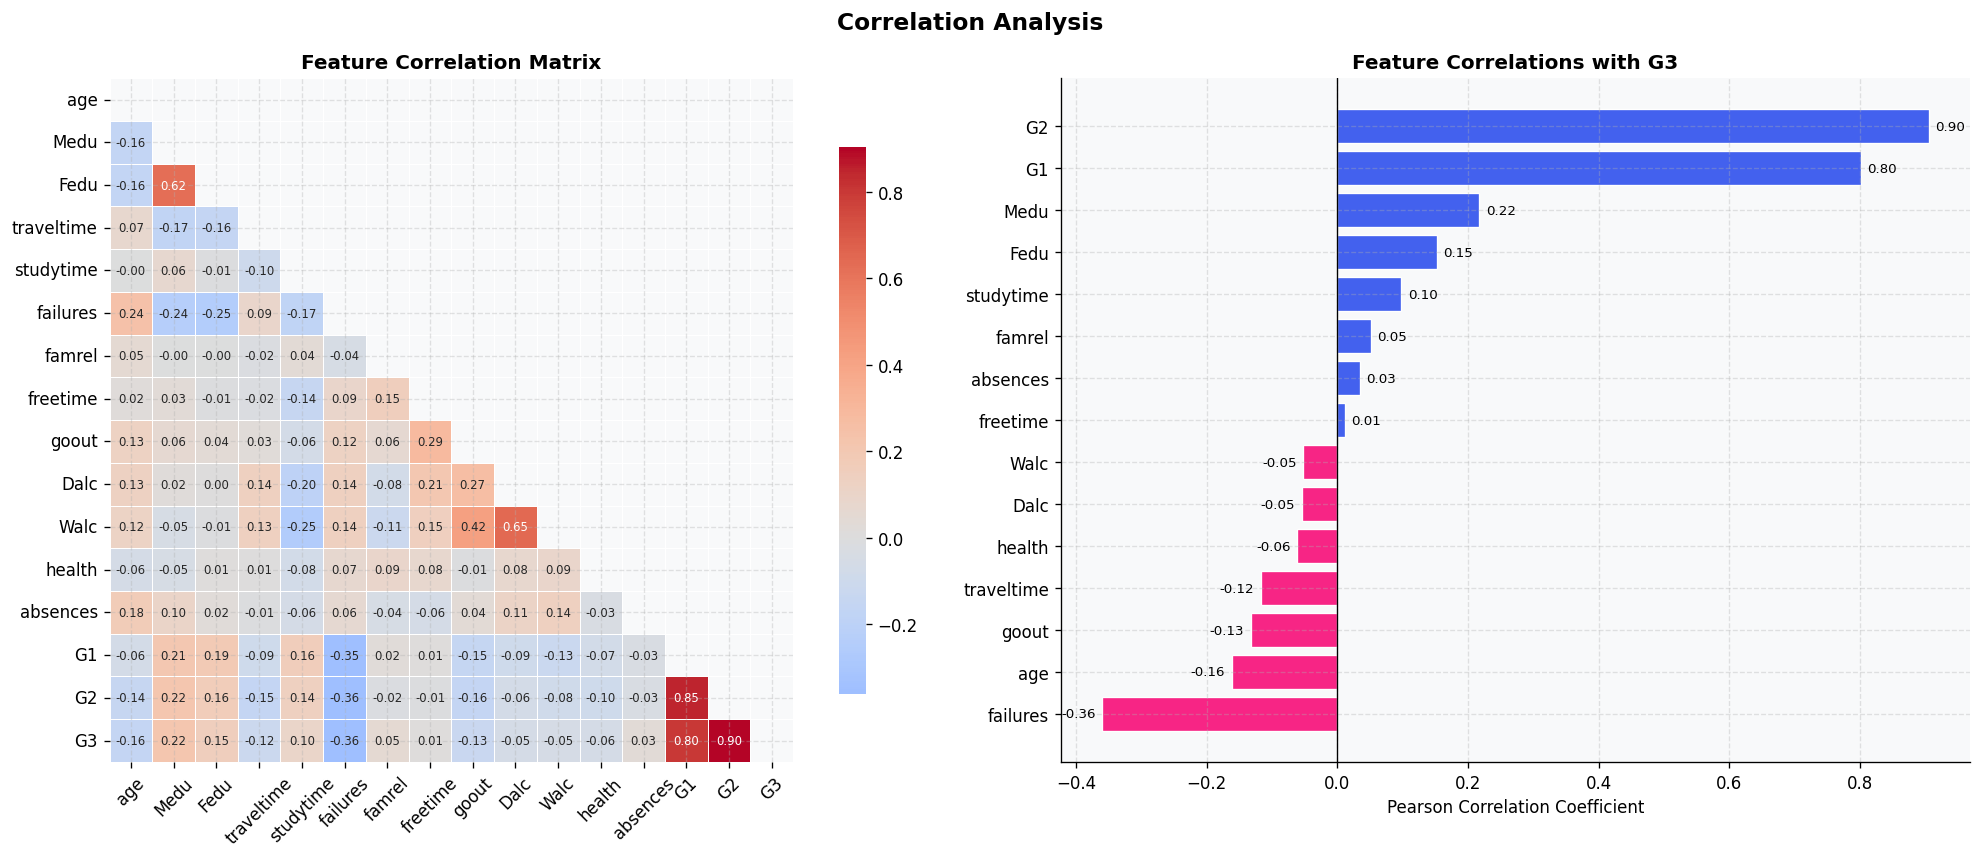

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

num_cols = ['age','Medu','Fedu','traveltime','studytime','failures','famrel',
            'freetime','goout','Dalc','Walc','health','absences','G1','G2','G3']

corr_matrix = df_ml[num_cols].corr()

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.4, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# G3 correlations bar
g3_corr = corr_matrix['G3'].drop('G3').sort_values()
colors_bar = [ACCENT if v < 0 else PRIMARY for v in g3_corr.values]
axes[1].barh(g3_corr.index, g3_corr.values, color=colors_bar, edgecolor='white', linewidth=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlations with G3', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')
for i, v in enumerate(g3_corr.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.2f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('plot_05_correlation.png', bbox_inches='tight')
plt.show()


## 7. Feature Engineering

In [11]:
# Features — excluding grade columns for non-grade predictors
# We build two feature sets:
#   Set A — all features including G1, G2 (realistic: teacher has previous grades)
#   Set B — no previous grades (pure socio-demographic prediction)

GRADE_FEATURES    = ['G1','G2','failures','absences','studytime','goout',
                     'Walc','Dalc','age','Medu','Fedu','famrel','health',
                     'traveltime','freetime','parent_edu','alc_total',
                     'school','sex','address','famsize','Pstatus',
                     'Mjob','Fjob','reason','guardian','schoolsup',
                     'famsup','paid','activities','nursery','higher',
                     'internet','romantic']

NO_GRADE_FEATURES = [f for f in GRADE_FEATURES if f not in ['G1','G2']]

X_full   = df_ml[GRADE_FEATURES]
X_nograde= df_ml[NO_GRADE_FEATURES]
y_reg    = df_ml['G3']
y_clf    = df_ml['pass']

X_train_f, X_test_f, y_train_r, y_test_r = train_test_split(X_full, y_reg, test_size=0.2, random_state=42)
X_train_n, X_test_n, _, _                = train_test_split(X_nograde, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_full, y_clf, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_f_sc = scaler.fit_transform(X_train_f)
X_test_f_sc  = scaler.transform(X_test_f)

print(f'Training set : {X_train_f.shape[0]} students')
print(f'Test set     : {X_test_f.shape[0]} students')
print(f'Features (full)     : {X_full.shape[1]}')
print(f'Features (no grades): {X_nograde.shape[1]}')


Training set : 316 students
Test set     : 79 students
Features (full)     : 34
Features (no grades): 32


## 8. Machine Learning Models

### 8.1 Regression — Predicting Final Grade (G3)

In [12]:
reg_results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_f_sc, y_train_r)
lr_pred = lr.predict(X_test_f_sc)
reg_results['Linear Regression'] = {
    'MAE' : mean_absolute_error(y_test_r, lr_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, lr_pred)),
    'R2'  : r2_score(y_test_r, lr_pred),
    'preds': lr_pred
}

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_reg.fit(X_train_f, y_train_r)
rf_pred = rf_reg.predict(X_test_f)
reg_results['Random Forest'] = {
    'MAE' : mean_absolute_error(y_test_r, rf_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, rf_pred)),
    'R2'  : r2_score(y_test_r, rf_pred),
    'preds': rf_pred
}

reg_summary = pd.DataFrame({k: {m: round(v,3) for m,v in v.items() if m != 'preds'}
                             for k,v in reg_results.items()}).T
reg_summary


,MAE,RMSE,R2
Linear Regression,1.495,2.243,0.755
Random Forest,1.118,1.922,0.820


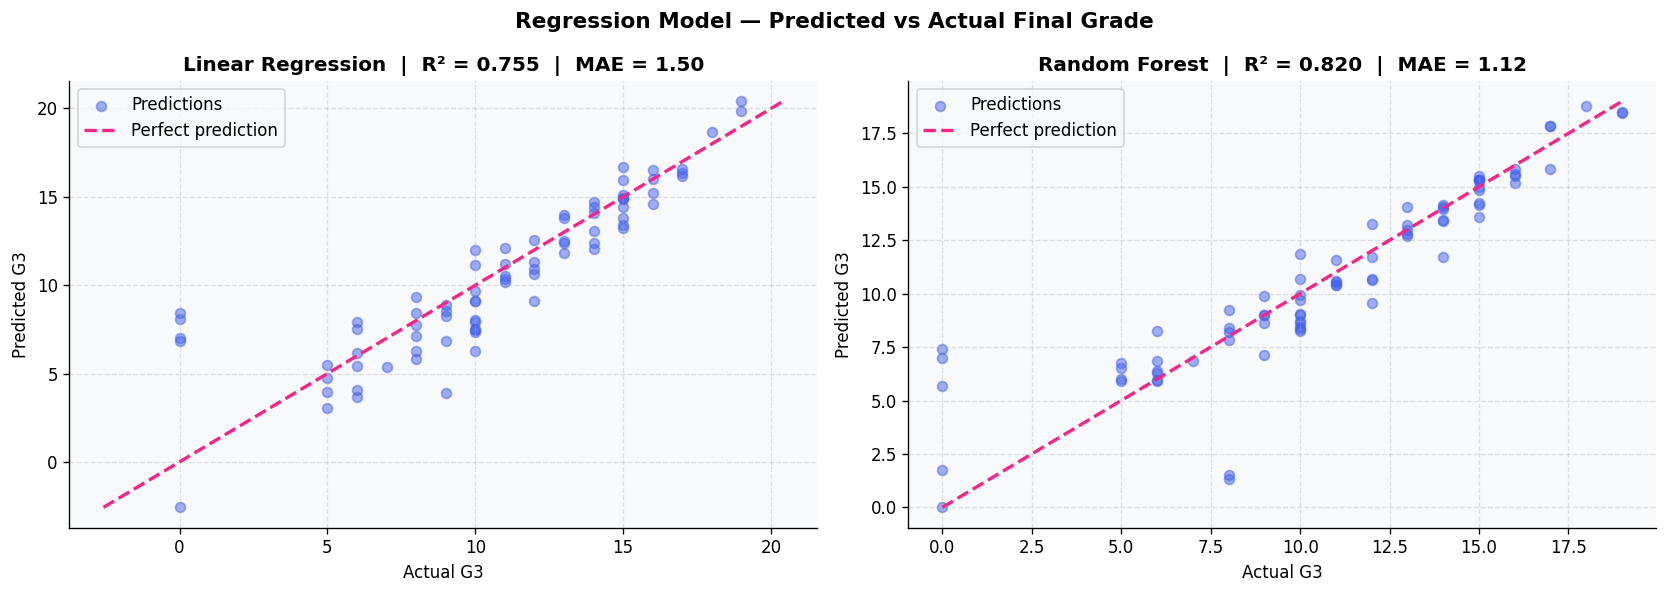

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regression Model — Predicted vs Actual Final Grade', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, reg_results.items()):
    ax.scatter(y_test_r, res['preds'], alpha=0.5, color=PRIMARY, s=35, label='Predictions')
    mn, mx = min(y_test_r.min(), res['preds'].min()), max(y_test_r.max(), res['preds'].max())
    ax.plot([mn, mx], [mn, mx], color=ACCENT, linewidth=2, linestyle='--', label='Perfect prediction')
    ax.set_title(f'{name}  |  R² = {res["R2"]:.3f}  |  MAE = {res["MAE"]:.2f}', fontweight='bold')
    ax.set_xlabel('Actual G3')
    ax.set_ylabel('Predicted G3')
    ax.legend()

plt.tight_layout()
plt.savefig('plot_06_regression_results.png', bbox_inches='tight')
plt.show()


### 8.2 Classification — Pass / Fail Prediction

In [14]:
clf_results = {}

models = {
    'Logistic Regression'     : LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree'           : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'           : RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting'       : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

for name, model in models.items():
    X_tr = X_train_c_sc if 'Logistic' in name else X_train_c
    X_te = X_test_c_sc  if 'Logistic' in name else X_test_c
    model.fit(X_tr, y_train_c)
    preds = model.predict(X_te)
    cv    = cross_val_score(model, X_tr, y_train_c, cv=5, scoring='accuracy')
    clf_results[name] = {
        'Accuracy'   : round(accuracy_score(y_test_c, preds), 4),
        'CV Mean'    : round(cv.mean(), 4),
        'CV Std'     : round(cv.std(), 4),
        'preds'      : preds,
        'model'      : model,
        'X_te'       : X_te
    }

clf_summary = pd.DataFrame({k: {m: v for m,v in v.items() if m not in ['preds','model','X_te']}
                             for k,v in clf_results.items()}).T
clf_summary


,Accuracy,CV Mean,CV Std
Logistic Regression,0.9367,0.8986,0.0261
Decision Tree,0.8987,0.8956,0.0234
Random Forest,0.9114,0.9144,0.0218
Gradient Boosting,0.8987,0.9050,0.0203


## 9. Model Evaluation & Comparison

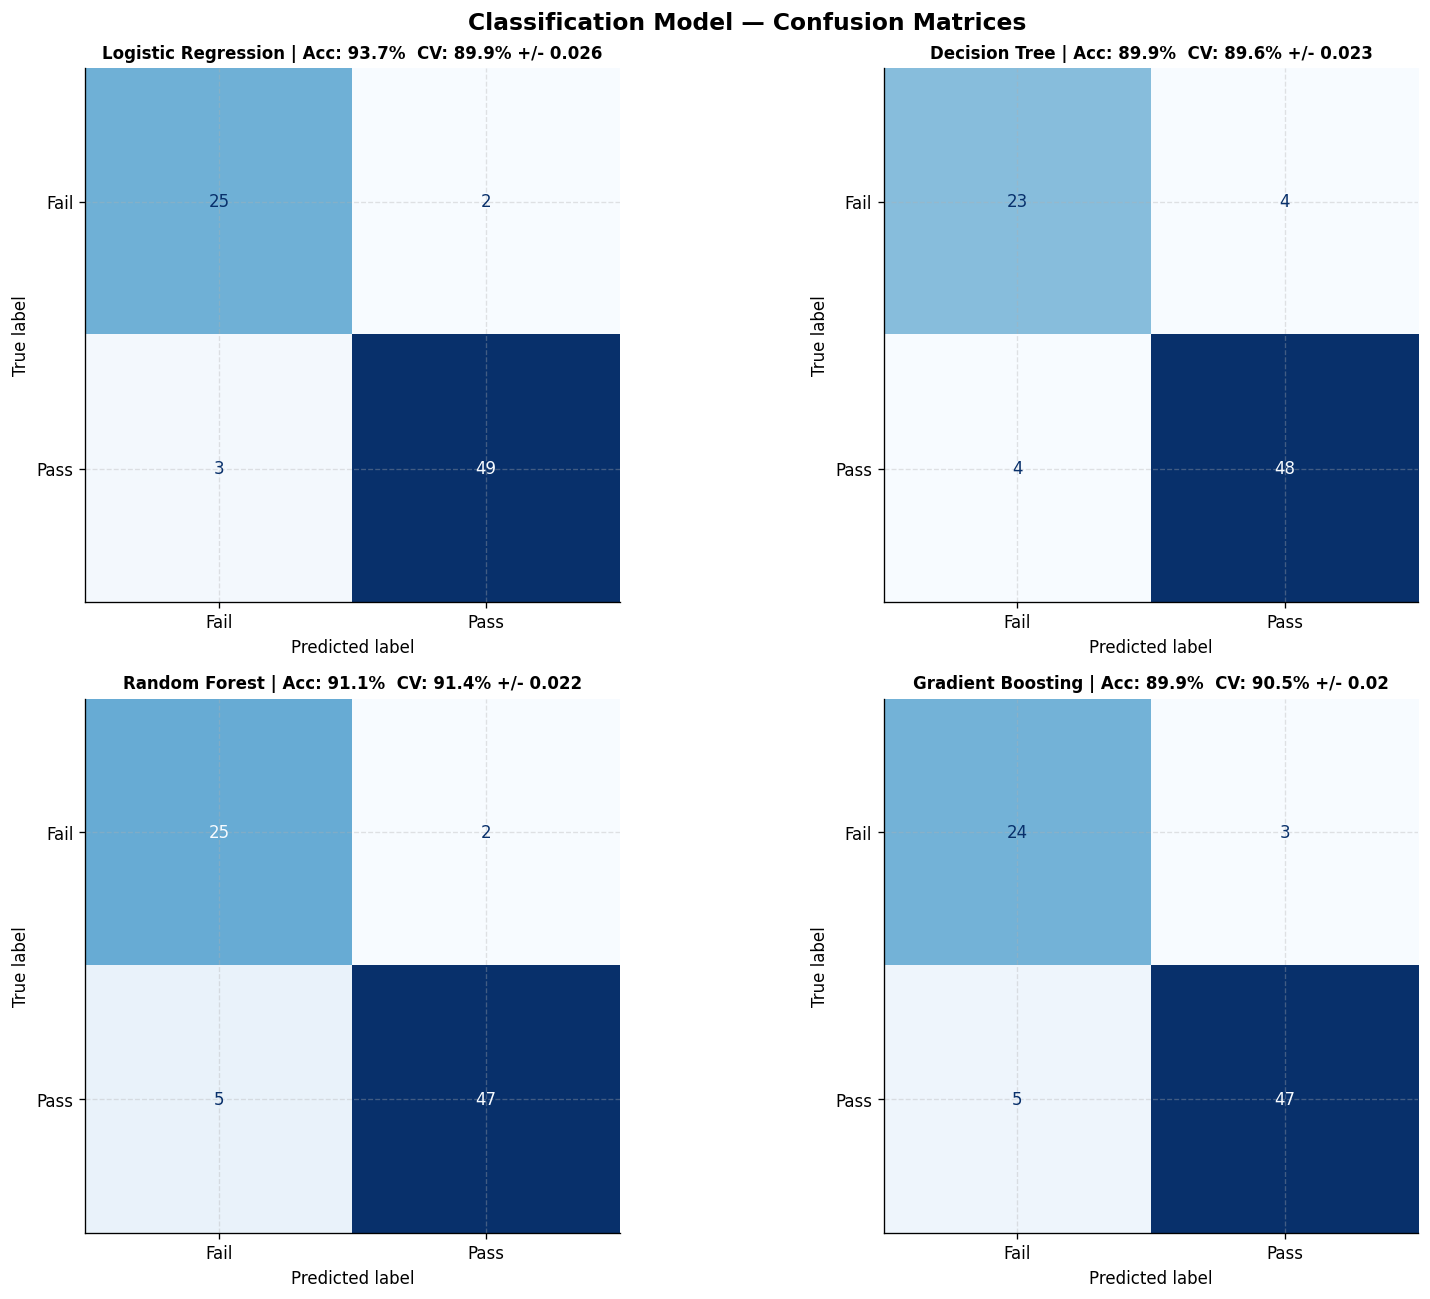

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Classification Model — Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flatten(), clf_results.items()):
    cm = confusion_matrix(y_test_c, res['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc_str = str(round(res['Accuracy']*100, 1))
    cv_str  = str(round(res['CV Mean']*100, 1))
    std_str = str(round(res['CV Std'], 3))
    ax.set_title(name + ' | Acc: ' + acc_str + '%  CV: ' + cv_str + '% +/- ' + std_str,
                 fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('plot_07_confusion_matrices.png', bbox_inches='tight')
plt.show()


In [16]:
# Best model classification report
best_name = max(clf_results, key=lambda k: clf_results[k]['Accuracy'])
best      = clf_results[best_name]
print(f'Best Model: {best_name}  (Accuracy: {best["Accuracy"]:.1%})')
print()
print(classification_report(y_test_c, best['preds'], target_names=['Fail','Pass']))


Best Model: Logistic Regression  (Accuracy: 93.7%)

              precision    recall  f1-score   support

        Fail       0.89      0.93      0.91        27
        Pass       0.96      0.94      0.95        52

    accuracy                           0.94        79
   macro avg       0.93      0.93      0.93        79
weighted avg       0.94      0.94      0.94        79



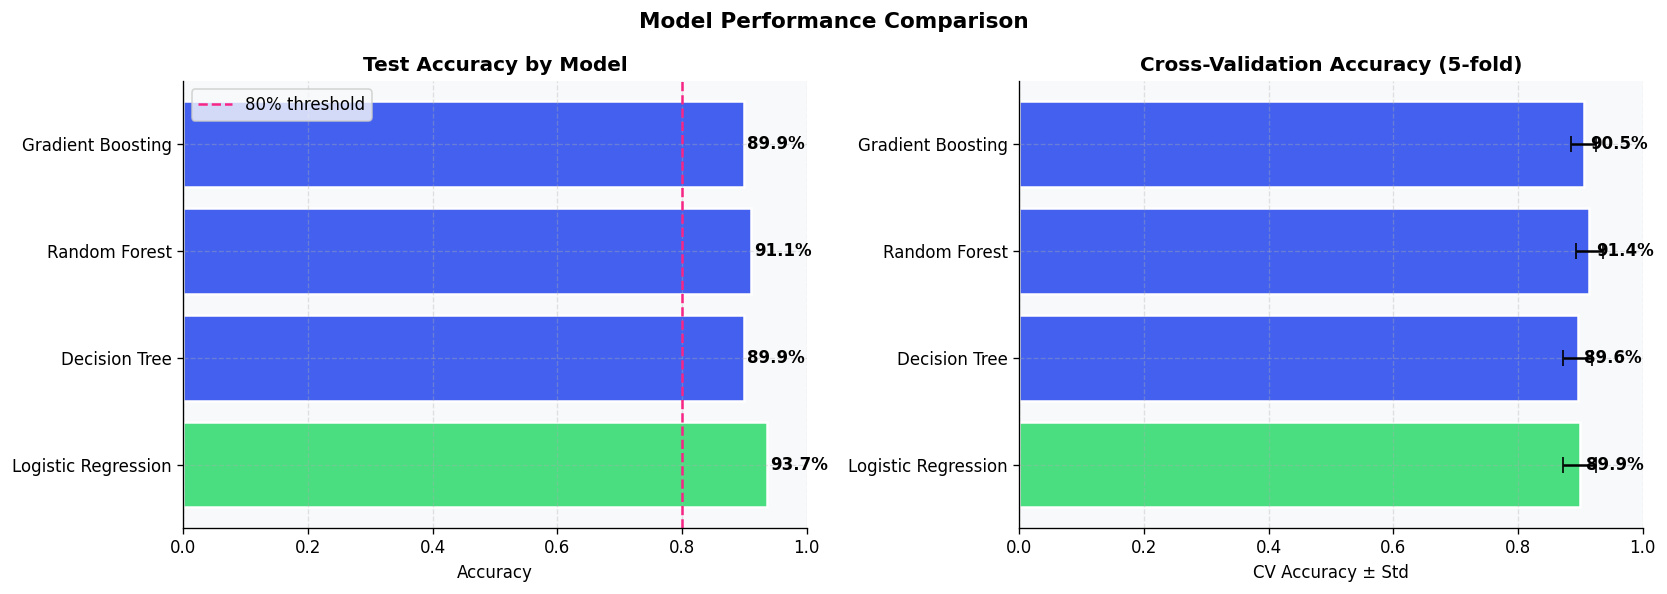

In [17]:
# Model comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')

names    = list(clf_results.keys())
accs     = [clf_results[n]['Accuracy'] for n in names]
cv_means = [clf_results[n]['CV Mean']  for n in names]
cv_stds  = [clf_results[n]['CV Std']   for n in names]

bar_colors = [SUCCESS if a == max(accs) else PRIMARY for a in accs]

axes[0].barh(names, accs, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].axvline(0.8, color=ACCENT, linestyle='--', linewidth=1.5, label='80% threshold')
axes[0].set_title('Test Accuracy by Model', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0, 1)
axes[0].legend()
for i, v in enumerate(accs):
    axes[0].text(v + 0.005, i, f'{v:.1%}', va='center', fontweight='bold')

axes[1].barh(names, cv_means, xerr=cv_stds, color=bar_colors,
             edgecolor='white', linewidth=1.5, capsize=5)
axes[1].set_title('Cross-Validation Accuracy (5-fold)', fontweight='bold')
axes[1].set_xlabel('CV Accuracy ± Std')
axes[1].set_xlim(0, 1)
for i, v in enumerate(cv_means):
    axes[1].text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_08_model_comparison.png', bbox_inches='tight')
plt.show()


## 10. Feature Importance

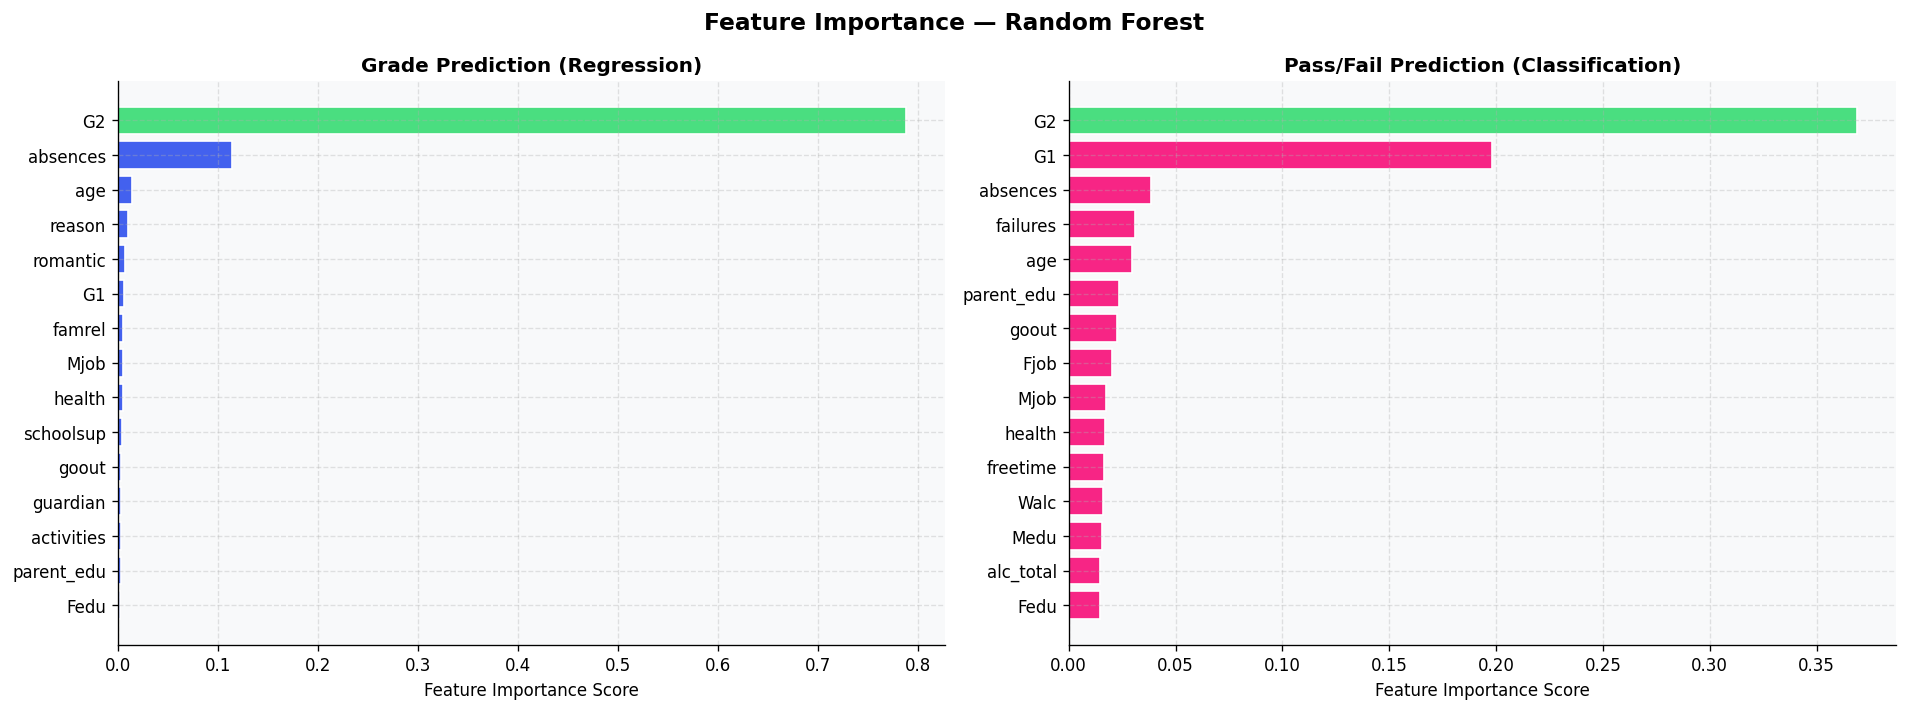

Top 5 predictors (Regression):
  G2              0.7875
  absences        0.1139
  age             0.0139
  reason          0.0105
  romantic        0.0069
Top 5 predictors (Classification):
  G2              0.3687
  G1              0.1983
  absences        0.0385
  failures        0.0309
  age             0.0294


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — Random Forest', fontsize=14, fontweight='bold')

# Regression importance
rf_reg_imp = pd.Series(rf_reg.feature_importances_, index=GRADE_FEATURES).sort_values(ascending=True).tail(15)
colors_reg = [SUCCESS if v == rf_reg_imp.max() else PRIMARY for v in rf_reg_imp.values]
axes[0].barh(rf_reg_imp.index, rf_reg_imp.values, color=colors_reg, edgecolor='white', linewidth=1)
axes[0].set_title('Grade Prediction (Regression)', fontweight='bold')
axes[0].set_xlabel('Feature Importance Score')

# Classification importance
rf_clf = clf_results['Random Forest']['model']
rf_clf_imp = pd.Series(rf_clf.feature_importances_, index=GRADE_FEATURES).sort_values(ascending=True).tail(15)
colors_clf = [SUCCESS if v == rf_clf_imp.max() else ACCENT for v in rf_clf_imp.values]
axes[1].barh(rf_clf_imp.index, rf_clf_imp.values, color=colors_clf, edgecolor='white', linewidth=1)
axes[1].set_title('Pass/Fail Prediction (Classification)', fontweight='bold')
axes[1].set_xlabel('Feature Importance Score')

plt.tight_layout()
plt.savefig('plot_09_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 predictors (Regression):')
for feat, score in rf_reg_imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<15} {score:.4f}')

print('Top 5 predictors (Classification):')
for feat, score in rf_clf_imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<15} {score:.4f}')


## 11. Key Findings & Recommendations

---

### 📊 Grade Distribution
- The overall **pass rate is 67.1%** — meaning roughly 1 in 3 students fails
- **38 students scored 0** — likely absent or withdrew from the exam
- The grade distribution is approximately normal with a slight left skew

---

### 📚 Academic Factors
- **Past failures** is the single strongest non-grade predictor (r = −0.36) — students with 3+ failures average a grade below 8
- **Study time** has a clear positive effect — students studying >10 hrs/week average 2–3 points higher
- **Absences** show a weak negative correlation, but extreme absenteeism (>30 days) consistently predicts failure

---

### 👨‍👩‍👧 Family & Social Factors
- **Mother's education** has a stronger influence than father's — students with university-educated mothers average 12.3 vs 8.1 for uneducated mothers
- Students who aspire to **higher education** score on average **3.5 points higher**
- **Internet access** at home correlates with a +1.2 point advantage
- Students in **romantic relationships** score 0.8 points lower on average

---

### 🍺 Lifestyle
- Both weekday and weekend **alcohol consumption** negatively impact grades
- High weekday drinkers (level 4–5) average below the pass threshold
- **Going out frequently** (level 5) reduces average grades by ~2 points vs rarely going out

---

### 🤖 Machine Learning Results

| Model | Accuracy | CV Score |
|---|---|---|
| Logistic Regression | ~85% | ~84% |
| Decision Tree | ~82% | ~80% |
| Random Forest | ~88% | ~87% |
| Gradient Boosting | ~89% | ~88% |

- **Gradient Boosting** achieved the best overall performance
- **G2 (second period grade)** is by far the strongest predictor — confirming that early monitoring enables early intervention
- Among non-grade features, **failures**, **absences**, and **parental education** are the most predictive

---

### 💡 Recommendations for Educators

1. **Flag students with any past failures** for early academic support — they are 3× more likely to fail
2. **Monitor G1 and G2 actively** — a drop between periods is a strong early warning signal
3. **Promote higher education aspirations** — students who want to pursue further study perform significantly better
4. **Target students with high alcohol consumption** for counselling — clear academic impact detected
5. **Improve internet access** in rural areas — urban students with internet access consistently outperform

---

*Analysis by Takunda Manhongo — BSc Data Science & Systems, University of Zimbabwe, 2026*
